# **BASELINE MODEL**

In this notebook, we will create the baseline model with no physics-informed loss function and a PINN with the modified loss function to account for the physics. We start off with our usual imports,

In [7]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
import torchvision
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Torch Vision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Torch Vision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


### 1. Loading Data

In [8]:
class FlowDataset(Dataset):
    """Class container for the training data."""

    def __init__(self, split=None, data_tuple=None):
        """Loads, scales (using min-max) and converts the data into Tensors."""

        # Loading,
        data = np.load(f"data_{split}.npz")
        self.X, self.y, self.flags = data["X"], data["y"], data["flags"]
        self.n_samples = self.X.shape[0]

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32))
        self.y = torch.from_numpy(self.y.astype(np.float32))
        self.flags = torch.from_numpy(self.flags.astype(np.int64))

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.flags[idx]
    
    def __len__(self):
        return self.n_samples

class Scaler():
    """Performs per feature min-max scaling. Note that we use the Tensor datatype (not NumPy arrays)."""

    def __init__(self):
        self.X_maxs, self.X_mins = None, None
        self.y_maxs, self.y_mins = None, None
        self.epsilon = 1e-8

    def fit(self, dataset):
        """Fit the scaler to the given data"""

        # Storing dataset,
        self.dataset = dataset

        # Computing the maximum and minimum values,
        X, y = dataset.X, dataset.y
        self.X_maxs, self.X_mins = torch.max(X, dim=0).values, torch.min(X, dim=0).values
        self.y_maxs, self.y_mins = torch.max(y, dim=0).values, torch.min(y, dim=0).values

        return None

    def transform(self, dataset):
        """Performs the min-max scaling on the given data."""

        # Performing min-max scaling,
        X, y = dataset.X, dataset.y
        X_scaled = (X - self.X_mins)/(self.X_maxs - self.X_mins + self.epsilon)
        y_scaled = (y - self.y_mins)/(self.y_maxs - self.y_mins + self.epsilon)

        # Reconstructing dataset,
        dataset.X, dataset.y = X_scaled, y_scaled

        return dataset

    def fit_transform(self, dataset):
        """Fits the scaler on the given data and transforms it."""

        # Fitting scaler,
        self.fit(dataset)

        # Performing min-max scaling,
        dataset_scaled = self.transform(dataset)

        return dataset_scaled

# Loading training, testing and validation data,
train_data = FlowDataset("train")
test_data = FlowDataset("test")
val_data = FlowDataset("validation")

# Performing mix-max scaling,
scaler = Scaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)
val_data = scaler.transform(val_data)

# Creating dataloaders,
BATCH_SIZE = 128
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, shuffle=False)

Inspecting the data,

In [9]:
for (X, y, flags_batch) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}, flags: {flags_batch.shape}")
    break

X: torch.Size([128, 3]), y: torch.Size([128, 3]), flags: torch.Size([128])


### 2. Model Creation

In this section we create the model architecture for the baseline model. We opt for a simple MLP with 3 hidden fully-connected layers consisting of `128` neurons with ReLU activiations. The network is small with just under `34,000` trainable parameters. The input layer takes a spatial-temporal point $(x, y, t)$ while the output layer returns the components of the velocity field and the scaler pressure field $(u, v, p)$.  

In [10]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=3, out_features=128)
        self.fc2 = Linear(in_features=128, out_features=128)
        self.fc3 = Linear(in_features=128, out_features=128)
        self.fc4 = Linear(in_features=128, out_features=3)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))

        return x

Testing the forward propagation using `torchinfo`,

In [11]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 3))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [128, 3]                  --
├─Linear: 1-1                            [128, 128]                512
├─Linear: 1-2                            [128, 128]                16,512
├─Linear: 1-3                            [128, 128]                16,512
├─Linear: 1-4                            [128, 3]                  387
Total params: 33,923
Trainable params: 33,923
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.34
Input size (MB): 0.00
Forward/backward pass size (MB): 0.40
Params size (MB): 0.14
Estimated Total Size (MB): 0.53

### 3. Model Training (Baseline)

For the baseline model, we train it with `Adam` optimiser minimising the `MSE` loss until it reaches the threshold for overfitting.

In [ ]:
# Hyperparameters,
patience = 5
max_epochs = 25
lr = 1e-3

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = torch.nn.MSELoss()

"""TRAINING LOOP"""
train_losses = []
val_losses = []
best_val_loss = float('inf')  
epochs_no_improve = 0
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y, flags) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y, flags = X.to(device), y.to(device), flags.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass.
        loss = loss_fn(y_pred, y) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    """================= VALIDATION ================="""
    model.eval() # <-- Switching to evaluation mode.
    val_running_loss = 0.0

    # Not tracking gradients,
    with torch.no_grad():
        for X_val, y_val, flags in val_loader:
            X_val, y_val, flags = X_val.to(device), y_val.to(device), flags.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f} | validation_loss: {val_loss:.6f}")

    """ ================= EARLY STOPPING MECHANISM ================="""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Saving checkpoint,
        torch.save(model.state_dict(), "best_model_baseline.pth")

    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print("TRAINING HALTED.")
        break

Training on: cpu
Epoch 1 | training_loss: 0.007840 | validation_loss: 0.005059
Epoch 2 | training_loss: 0.004972 | validation_loss: 0.004925
Epoch 3 | training_loss: 0.004439 | validation_loss: 0.003489
Epoch 4 | training_loss: 0.001895 | validation_loss: 0.001148
Epoch 5 | training_loss: 0.000941 | validation_loss: 0.000618
Epoch 6 | training_loss: 0.000619 | validation_loss: 0.000546
Epoch 7 | training_loss: 0.000508 | validation_loss: 0.000755
Epoch 8 | training_loss: 0.000429 | validation_loss: 0.000455
Epoch 9 | training_loss: 0.000407 | validation_loss: 0.000340
Epoch 10 | training_loss: 0.000358 | validation_loss: 0.000285
Epoch 11 | training_loss: 0.000328 | validation_loss: 0.000313
Epoch 12 | training_loss: 0.000324 | validation_loss: 0.000233
Epoch 13 | training_loss: 0.000301 | validation_loss: 0.000445
Epoch 14 | training_loss: 0.000290 | validation_loss: 0.000192
Epoch 15 | training_loss: 0.000284 | validation_loss: 0.000265
Epoch 16 | training_loss: 0.000277 | validation

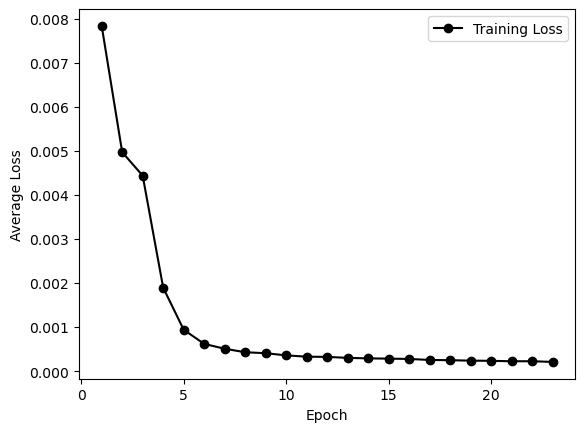

In [14]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, marker="o", color="black", label="Training Loss")
#plt.plot(epochs, val_losses, marker="o", color="orange", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

### 4. Model Prediction

Let us create a function for model inference,

In [15]:
def predict(model, dataloader, device="cpu"):
    """This function performs model inference."""

    # Switch model to evaluation mode,
    model.eval()

    # Creating the predictions array,
    y_preds = []

    # Looping over all batches,
    with torch.no_grad():
        for X in dataloader:

            # Moving input tensor to training device,
            X = X.to(device).float()
    
            # Model forward pass,
            y_pred = model(X)
            y_pred = y_pred.cpu() # <-- Move to CPU.
            y_preds.append(y_pred)

    # Concatening batch predictions,
    y_preds = torch.cat(y_preds, dim=0)

    # Returning predictions,
    return y_preds

Now we generate the model predictions (remember that we work with Tensors and not NumPy arrays),

In [16]:
# Loading the required simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = torch.from_numpy(file["t"][:]).float()
    x = torch.from_numpy(file["x"][:]).float()
    y = torch.from_numpy(file["y"][:]).float()

X = torch.stack([
    x.reshape(-1),
    y.reshape(-1),
    torch.repeat_interleave(t, x.shape[1])
], dim=1)

# Scaling the simulation data,
X_scaled = (X - scaler.X_mins)/(scaler.X_maxs - scaler.X_mins + scaler.epsilon)

# Creating dataloader,
sim_loader = DataLoader(X_scaled, batch_size=BATCH_SIZE, shuffle=False)

# Generating model predictions,
y_pred = predict(model, dataloader=sim_loader, device="cpu")

# Reversing the scaling on the predictions,
y_pred = y_pred*(scaler.y_maxs - scaler.y_mins + scaler.epsilon) + scaler.y_mins

Now we have to convert our predictions `y_pred` from a Tensor to NumPy arrays that represent the predicted velocity and pressure fields. We must ensure that their shapes are consistent with the original simulation data such that we can use them in the simulation suite. 

In [17]:
# Converting to correct format,
n_time_steps, n_nodes = 201,  82872
y_pred = y_pred.numpy()
y_pred = y_pred.reshape(n_time_steps, n_nodes, 3) # Reshaping.
u_pred, v_pred, p_pred = y_pred[:, :, 0], y_pred[:, :, 1], y_pred[:, :, 2] # Extracting predicted fields.

# Saving predictions,
np.save(file="u_pred_baseline.npy", arr=u_pred)
np.save(file="v_pred_baseline.npy", arr=v_pred)
np.save(file="p_pred_baseline.npy", arr=p_pred)